## Ensemble Approach

In [1]:
!pip install numpy
!pip install matplotlib
!pip install scipy
!pip install scikit-learn
!pip install pandas
!pip install seaborn
!pip install tensorflow
!pip install torch
!pip install xgboost
!pip install torchvision
!pip install opencv-python


In [2]:
#Section 1 - Import Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import cv2
import random
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from torchvision import models
from sklearn.metrics import accuracy_score

In [3]:
#Section 2 - Device Configuration

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple GPU (MPS)")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using device: cpu
Using Apple GPU (MPS)


In [4]:
#Section 3 - Inmage Transformations 

#This section is for preprocessing all images before training so it resize all images to same size, normalizes the pixel values to be between 0
#and convert images from pixels.

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [5]:
#Section 4 - Custom Dataset Class

#This willl load images from folders.

class LeafDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        
        if isinstance(image, str):

            image = cv2.imread(image)

            image = cv2.cvtColor(
                image,
                cv2.COLOR_BGR2RGB
            )
        else:

            image = image.astype("uint8")
        
        # Apply transformations if any
        if self.transform:
            image = self.transform(image)
        
        return image, label

In [6]:
#Section 5 - Load Dataset Paths and Labels

#This section collects all image paths and labels and label mapping will be 0 - Non Stress and 1 - Streess.
#
# 1. Tomato Dataset
# 2. Maize Folder Dataset
# 3. Maize .npy Dataset
#
# Tomato Dataset Mapping
#
# 100%_field_capacity → Non-stress (0)
# 75%_field_capacity  → Stress (1)
# 50%_field_capacity  → Stress (1)
# 25%_field_capacity  → Stress (1)

def load_tomato_dataset(dataset_path):
    image_paths = []
    labels = []

    stress_folders = [
        "25%_field_capacity",
        "50%_field_capacity",
        "75%_field_capacity"
    ]

    non_stress_folders = [
        "100%_field_capacity"
    ]

    for folder in os.listdir(dataset_path):
        if folder.startswith("."):
            continue
        folder_path = os.path.join(dataset_path, folder)

        # Skip if not directory
        if not os.path.isdir(folder_path):
            continue

        #Assign Labels
        if folder in stress_folders:
            label = 1  # Stress
        else:
            label = 0  # Non-stress

        for img_file in os.listdir(folder_path):
            if img_file.startswith("."):
                continue

            img_path = os.path.join(folder_path, img_file)
            image_paths.append(img_path)
            labels.append(label)
            
    return image_paths, labels
 

In [7]:
# Maize Folder Dataset Mapping
#
# WW  → Non-stress (0)
# MIS → Stress (1)
# MOD → Stress (1)
# WS  → Stress (1)

def load_maize_dataset(dataset_path):

    image_paths = []
    labels = []

    stress_folders = ["MIS", "MOD", "WS"]
    non_stress_folders = ["WW"]

    for folder in os.listdir(dataset_path):

        if folder.startswith("."):
            continue

        folder_path = os.path.join(dataset_path, folder)

        if not os.path.isdir(folder_path):
            continue

        # Assign labels
        if folder in stress_folders:
            label = 1
        else:
            label = 0

        for img_file in os.listdir(folder_path):

            if img_file.startswith("."):
                continue

            img_path = os.path.join(folder_path, img_file)

            image_paths.append(img_path)
            labels.append(label)

    return image_paths, labels

In [8]:
#Load .npy maize dataset

#In this the important task is to check the format of lables for example 0 and 1 or labels are multicalss if that they need to be converted to binary labels.

npy_dataset_path = "/Users/manish/Documents/Semister 2/7. Project/Dataset/MaizeLeaf_dataset"

# Load arrays
train_maize2_data = np.load(os.path.join(npy_dataset_path, "trainData.npy"))
train_maize2_labels = np.load(os.path.join(npy_dataset_path, "trainLabel.npy"))

val_maize2_data = np.load(os.path.join(npy_dataset_path, "valData.npy"))
val_maize2_labels = np.load(os.path.join(npy_dataset_path, "valLabel.npy"))

test_maize2_data = np.load(os.path.join(npy_dataset_path, "testData.npy"))
test_maize2_labels = np.load(os.path.join(npy_dataset_path, "testLabel.npy"))

print("Train Shape:", train_maize2_data.shape)
print("Validation Shape:", val_maize2_data.shape)
print("Test Shape:", test_maize2_data.shape)

print("Unique Labels:", np.unique(train_maize2_labels))


Train Shape: (9580, 48, 48, 3)
Validation Shape: (2395, 48, 48, 3)
Test Shape: (6065, 48, 48, 3)
Unique Labels: [0 1 2]


In [9]:
# Original Labels:
# 0 - Well-watered
# 1 - Reduced-watered
# 2 - Drought-stressed
#
# New Labels:
# 0 - Non-stress
# 1 - Stress

train_maize2_labels = np.where(train_maize2_labels == 0, 0, 1)

val_maize2_labels = np.where(val_maize2_labels == 0, 0, 1)

test_maize2_labels = np.where(test_maize2_labels == 0, 0, 1)

# Check converted labels
print("Converted Train Labels:", np.unique(train_maize2_labels))
print("Converted Validation Labels:", np.unique(val_maize2_labels))
print("Converted Test Labels:", np.unique(test_maize2_labels))

Converted Train Labels: [0 1]
Converted Validation Labels: [0 1]
Converted Test Labels: [0 1]


In [10]:
# Check class distribution

print("Train Label Distribution:")
print(np.bincount(train_maize2_labels))

print("Validation Label Distribution:")
print(np.bincount(val_maize2_labels))

print("Test Label Distribution:")
print(np.bincount(test_maize2_labels))

Train Label Distribution:
[3200 6380]
Validation Label Distribution:
[ 875 1520]
Test Label Distribution:
[2245 3820]


In [11]:
#Section 7 - Load all datasets

tomato_image_path = "/Users/manish/Documents/Semister 2/7. Project/Dataset/Tomato Plant dataset/dataset"
maize_image_path = "/Users/manish/Documents/Semister 2/7. Project/Dataset/Maize Water Stress"

# Load Tomato Dataset
tomato_images, tomato_labels = load_tomato_dataset(tomato_image_path)

# Load Maize Dataset
maize_images, maize_labels = load_maize_dataset(maize_image_path)

print("Tomato Images:", len(tomato_images))
print("Maize Images:", len(maize_images))

print("Tomato Labels:", np.unique(tomato_labels))
print("Maize Labels:", np.unique(maize_labels))

Tomato Images: 20955
Maize Images: 400
Tomato Labels: [0 1]
Maize Labels: [0 1]


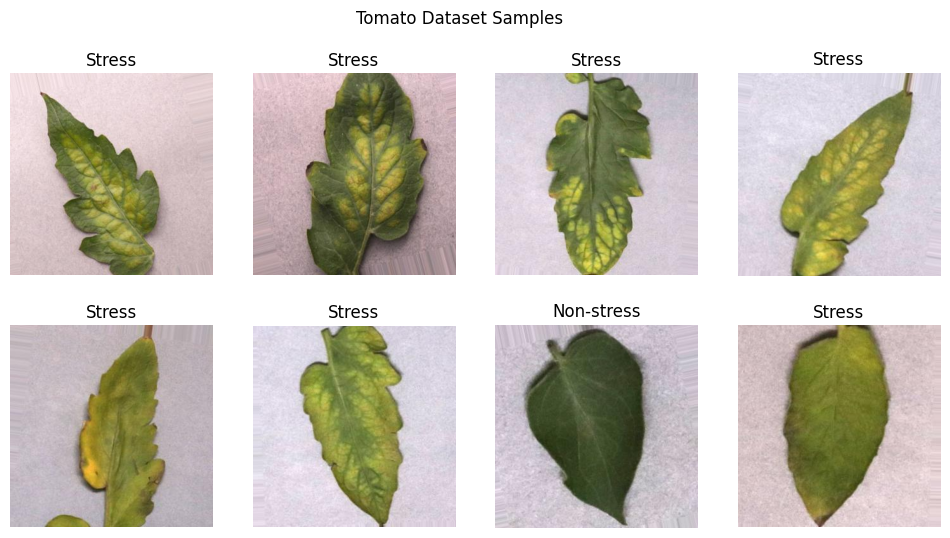

In [12]:
#Section 8 - View sample Images
label_names = {
    0: "Non-stress",
    1: "Stress"
}

random_indices = random.sample(range(len(tomato_images)), 8)

plt.figure(figsize=(12,6))

for i, idx in enumerate(random_indices):

    image = cv2.imread(tomato_images[idx])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    label = tomato_labels[idx]

    plt.subplot(2,4,i+1)
    plt.imshow(image)
    plt.title(label_names[label])   # class name
    plt.axis("off")

plt.suptitle("Tomato Dataset Samples")
plt.show()

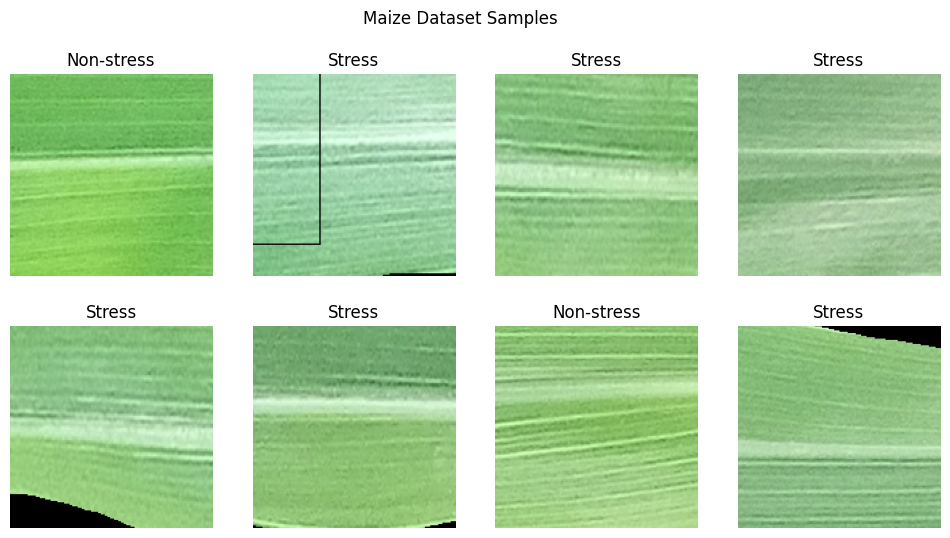

In [13]:
random_indices = random.sample(range(len(maize_images)), 8)

plt.figure(figsize=(12,6))

for i, idx in enumerate(random_indices):

    image = cv2.imread(maize_images[idx])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    label = maize_labels[idx]

    plt.subplot(2,4,i+1)
    plt.imshow(image)
    plt.title(label_names[label])   # class name
    plt.axis("off")

plt.suptitle("Maize Dataset Samples")
plt.show()

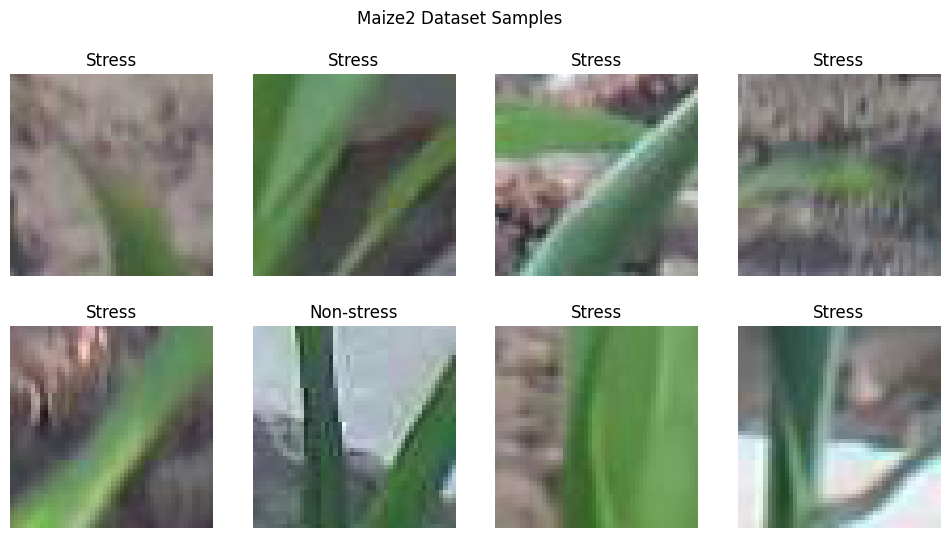

In [14]:
# Random sample indices
random_indices = random.sample(range(len(train_maize2_data)), 8)

plt.figure(figsize=(12,6))

for i, idx in enumerate(random_indices):

    # Directly get image array
    image = train_maize2_data[idx]

    # Get label
    label = train_maize2_labels[idx]

    plt.subplot(2,4,i+1)

    # Display image
    plt.imshow(image.astype("uint8"))

    plt.title(label_names[label])

    plt.axis("off")

plt.suptitle("Maize2 Dataset Samples")

plt.show()

In [15]:
#Section 9 - Train Test Split

train_tomato_data, temp_tomato_data, train_tomato_labels, temp_tomato_labels = train_test_split(
    tomato_images,
    tomato_labels,
    test_size=0.30,
    random_state=42,
    stratify=tomato_labels
)

val_tomato_data, test_tomato_data, val_tomato_labels, test_tomato_labels = train_test_split(
    temp_tomato_data,
    temp_tomato_labels,
    test_size=0.50,
    random_state=42,
    stratify=temp_tomato_labels
)

print("Tomato Train:", len(train_tomato_data))
print("Tomato Validation:", len(val_tomato_data))
print("Tomato Test:", len(test_tomato_data))

Tomato Train: 14668
Tomato Validation: 3143
Tomato Test: 3144


In [16]:
train_maize_data, temp_maize_data, train_maize_labels, temp_maize_labels = train_test_split(
    maize_images,
    maize_labels,
    test_size=0.30,
    random_state=42,
    stratify=maize_labels
)

# Second split → validation + test
val_maize_data, test_maize_data, val_maize_labels, test_maize_labels = train_test_split(
    temp_maize_data,
    temp_maize_labels,
    test_size=0.50,
    random_state=42,
    stratify=temp_maize_labels
)

print("Maize Train:", len(train_maize_data))
print("Maize Validation:", len(val_maize_data))
print("Maize Test:", len(test_maize_data))

Maize Train: 280
Maize Validation: 60
Maize Test: 60


In [17]:
#Section 10 - Create Dataset and Dataloaders

tomato_train_dataset = LeafDataset(
    train_tomato_data, train_tomato_labels, transform)

maize_train_dataset = LeafDataset(
    train_maize_data, train_maize_labels, transform)

maize2_train_dataset = LeafDataset(
    train_maize2_data, train_maize2_labels, transform)


tomato_val_dataset = LeafDataset(
    val_tomato_data, val_tomato_labels, transform)

maize_val_dataset = LeafDataset(
    val_maize_data, val_maize_labels, transform)

maize2_val_dataset = LeafDataset(
    val_maize2_data, val_maize2_labels, transform)


tomato_test_dataset = LeafDataset(
    test_tomato_data, test_tomato_labels, transform)

maize_test_dataset = LeafDataset(
    test_maize_data, test_maize_labels, transform)

maize2_test_dataset = LeafDataset(
    test_maize2_data, test_maize2_labels, transform)

batch_size = 32

tomato_train_loader = DataLoader(
    tomato_train_dataset, batch_size=batch_size, shuffle=True)
tomato_val_loader = DataLoader(
    tomato_val_dataset, batch_size=batch_size, shuffle=False)
tomato_test_loader = DataLoader(
    tomato_test_dataset, batch_size=batch_size, shuffle=False)

maize_train_loader = DataLoader(
    maize_train_dataset, batch_size=batch_size, shuffle=True)
maize_val_loader = DataLoader(
    maize_val_dataset, batch_size=batch_size, shuffle=False)
maize_test_loader = DataLoader(
    maize_test_dataset, batch_size=batch_size, shuffle=False)

maize2_train_loader = DataLoader(
    maize2_train_dataset, batch_size=batch_size, shuffle=True)
maize2_val_loader = DataLoader(
    maize2_val_dataset, batch_size=batch_size, shuffle=False)
maize2_test_loader = DataLoader(
    maize2_test_dataset, batch_size=batch_size, shuffle=False)

In [18]:
#Section 11 - Create MobileNetV2 Model

#It will be using pretrained MobileNetV2 and final layer will be modified to binary classification.

def create_model():

    model = models.mobilenet_v2(pretrained=True)

    model.classifier[1] = nn.Linear(
        model.last_channel,
        2
    )

    return model.to(device)

In [19]:
#Section 12 - Create Baseline Model

tomato_model = create_model()

maize_model = create_model()

maize2_model = create_model()

print("All Models Created Successfully")

/Users/manish/Library/r-miniconda-arm64/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/manish/Library/r-miniconda-arm64/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


All Models Created Successfully


In [20]:
#Section 13 - Loss Function and Optimizer

criterion = nn.CrossEntropyLoss()

# Tomato Optimizer
tomato_optimizer = torch.optim.Adam(
    tomato_model.parameters(),
    lr=0.001
)

# Maize Optimizer
maize_optimizer = torch.optim.Adam(
    maize_model.parameters(),
    lr=0.001
)

# Maize2 Optimizer
maize2_optimizer = torch.optim.Adam(
    maize2_model.parameters(),
    lr=0.001
)

In [21]:
#Section 14 - Trainining function

def train_model(model, train_loader, val_loader, optimizer, epochs=5):

    train_losses = []
    val_accuracies = []

    for epoch in range(epochs):

        #Traininig

        model.train()

        running_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)

        train_losses.append(avg_train_loss)

        #Validation

        model.eval()

        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                _, predicted = torch.max(outputs, 1)

                total += labels.size(0)

                correct += (predicted == labels).sum().item()

        val_accuracy = 100 * correct / total

        val_accuracies.append(val_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"Train Loss: {avg_train_loss:.4f}")
        print(f"Validation Accuracy: {val_accuracy:.2f}%")
        print("-" * 40)

    return train_losses, val_accuracies

In [22]:
#Section 15 - Train baseline model

print("Training Tomato Model")

train_model(
    tomato_model,
    tomato_train_loader,
    tomato_val_loader,
    tomato_optimizer,
    epochs=5
)

print("Training Maize Model")

train_model(
    maize_model,
    maize_train_loader,
    maize_val_loader,
    maize_optimizer,
    epochs=5
)

print("Training Maize2 Model")

train_model(
    maize2_model,
    maize2_train_loader,
    maize2_val_loader,
    maize2_optimizer,
    epochs=5
)


Training Tomato Model
Epoch [1/5]
Train Loss: 0.0303
Validation Accuracy: 99.65%
----------------------------------------
Epoch [2/5]
Train Loss: 0.0198
Validation Accuracy: 99.97%
----------------------------------------
Epoch [3/5]
Train Loss: 0.0114
Validation Accuracy: 99.84%
----------------------------------------
Epoch [4/5]
Train Loss: 0.0088
Validation Accuracy: 99.90%
----------------------------------------
Epoch [5/5]
Train Loss: 0.0122
Validation Accuracy: 99.55%
----------------------------------------
Training Maize Model
Epoch [1/5]
Train Loss: 0.2014
Validation Accuracy: 25.00%
----------------------------------------
Epoch [2/5]
Train Loss: 0.1370
Validation Accuracy: 26.67%
----------------------------------------
Epoch [3/5]
Train Loss: 0.0952
Validation Accuracy: 73.33%
----------------------------------------
Epoch [4/5]
Train Loss: 0.0598
Validation Accuracy: 81.67%
----------------------------------------
Epoch [5/5]
Train Loss: 0.0194
Validation Accuracy: 90.00

([0.14245653757515053,
  0.08965517024199168,
  0.0906950785483544,
  0.06816128196039548,
  0.06197649112980192],
 [86.05427974947808,
  95.78288100208768,
  93.06889352818372,
  91.8580375782881,
  94.07098121085595])

In [23]:
#Section 16 - Test function

def evaluate_model(model, test_loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    print(f"Test Accuracy: {accuracy:.2f}%")

    return accuracy

In [25]:
#Section 17 - Test Individual Models

print("Tomato Model Performance")
tomato_acc = evaluate_model(
    tomato_model,
    tomato_test_loader
)

print("Maize Model Performance")
maize_acc = evaluate_model(
    maize_model,
    maize_test_loader
)

print("Maize2 Model Performance")
maize2_acc = evaluate_model(
    maize2_model,
    maize2_test_loader
)

Tomato Model Performance
Test Accuracy: 99.49%
Maize Model Performance
Test Accuracy: 93.33%
Maize2 Model Performance
Test Accuracy: 93.98%


In [28]:
#Section 18 - Ensemble Learning Prediction Function

def ensemble_predict(image_tensor):

    tomato_model.eval()
    maize_model.eval()
    maize2_model.eval()

    with torch.no_grad():

        image_tensor = image_tensor.unsqueeze(0).to(device)

        # Tomato prediction
        pred1 = torch.softmax(
            tomato_model(image_tensor), dim=1
        )

        # Maize prediction
        pred2 = torch.softmax(
            maize_model(image_tensor), dim=1
        )

        # Maize2 prediction
        pred3 = torch.softmax(
            maize2_model(image_tensor), dim=1
        )

        # Average predictions
        final_pred = (pred1 + pred2 + pred3) / 3

        predicted_class = torch.argmax(final_pred, dim=1)

    return predicted_class.item()

In [30]:
#Section 19 - Test Ensemble Model

sample_image, sample_label = tomato_test_dataset[0]

prediction = ensemble_predict(sample_image)

print("Actual Label:", sample_label)
print("Predicted Label:", prediction)

Actual Label: 1
Predicted Label: 1


In [40]:
#Section 20 - Merge all test datasets for ensemble evaluation

# Combine all test images
merged_test_data = (
    test_tomato_data +
    test_maize_data +
    list(test_maize2_data)
)

# Combine all test labels

merged_test_labels = (
    list(test_tomato_labels) +
    list(test_maize_labels) +
    list(test_maize2_labels)
)

print("Total Test Images:", len(merged_test_data))
print("Total Test Labels:", len(merged_test_labels))

Total Test Images: 9269
Total Test Labels: 9269


In [44]:
merged_test_dataset = LeafDataset(
    merged_test_data,
    merged_test_labels,
    transform
)

In [46]:
#Section 20 - Ensemble Evaluation on Test Set

def evaluate_ensemble(merged_test_data):

    correct = 0
    total = 0

    for image, label in merged_test_data:

        prediction = ensemble_predict(image)

        total += 1

        if prediction == label:
            correct += 1

    accuracy = 100 * correct / total

    print(f"Ensemble Accuracy: {accuracy:.2f}%")

    return accuracy

In [47]:
ensemble_acc = evaluate_ensemble(
    merged_test_dataset
)

Ensemble Accuracy: 72.05%


# Version 2 - Fine-tunned Ensemble Model 

In [48]:
#Section 1 - Improved Data Augmentation

#Added some augmention to improve the generalization of model and to prevent overfitting.

improved_transform = transforms.Compose([

    transforms.ToPILImage(),

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(15),

    transforms.RandomResizedCrop(
        224,
        scale=(0.9,1.0)
    ),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
#Section2 - Create Improved Datasets

improved_tomato_train_dataset = LeafDataset(
    train_tomato_data, train_tomato_labels, improved_transform
)
improved_tomato_val_dataset = LeafDataset(
    val_tomato_data, val_tomato_labels, improved_transform
)
improved_tomato_test_dataset = LeafDataset(
    test_tomato_data, test_tomato_labels, improved_transform
)

improved_maize_train_dataset = LeafDataset(
    train_maize_data, train_maize_labels, improved_transform
)   
improved_maize_val_dataset = LeafDataset(
    val_maize_data, val_maize_labels, improved_transform
)
improved_maize_test_dataset = LeafDataset(
    test_maize_data, test_maize_labels, improved_transform
)

improved_maize2_train_dataset = LeafDataset(
    train_maize2_data, train_maize2_labels, improved_transform
)
improved_maize2_val_dataset = LeafDataset(
    val_maize2_data, val_maize2_labels, improved_transform
)
improved_maize2_test_dataset = LeafDataset(
    test_maize2_data, test_maize2_labels, improved_transform
)

In [52]:
#Section 3 - Improved Dataloaders

improved_tomato_train_loader = DataLoader(
    improved_tomato_train_dataset, batch_size=32, shuffle=True
)
improved_tomato_val_loader = DataLoader(
    improved_tomato_val_dataset, batch_size=32, shuffle=False
)
improved_tomato_test_loader = DataLoader(
    improved_tomato_test_dataset, batch_size=32, shuffle=False
)

improved_maize_train_loader = DataLoader(
    improved_maize_train_dataset, batch_size=32, shuffle=True
)
improved_maize_val_loader = DataLoader(
    improved_maize_val_dataset, batch_size=32, shuffle=False
)
improved_maize_test_loader = DataLoader(
    improved_maize_test_dataset, batch_size=32, shuffle=False
)

improved_maize2_train_loader = DataLoader(
    improved_maize2_train_dataset, batch_size=32, shuffle=True
)
improved_maize2_val_loader = DataLoader(
    improved_maize2_val_dataset, batch_size=32, shuffle=False
)
improved_maize2_test_loader = DataLoader(
    improved_maize2_test_dataset, batch_size=32, shuffle=False
)

In [53]:
#Section 4 - Improved Models 

improved_tomato_model = create_model()

improved_maize_model = create_model()

improved_maize2_model = create_model()

/Users/manish/Library/r-miniconda-arm64/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/manish/Library/r-miniconda-arm64/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [54]:
#Section 5  - Improved Optimizers

improved_tomato_optimizer = torch.optim.Adam(
    improved_tomato_model.parameters(),
    lr=0.0001
)

improved_maize_optimizer = torch.optim.Adam(
    improved_maize_model.parameters(),
    lr=0.0001
)

improved_maize2_optimizer = torch.optim.Adam(
    improved_maize2_model.parameters(),
    lr=0.0001
)

In [55]:
#Section 6 - Train Improved Models

print("Training Improved Tomato Model")
train_model(
    improved_tomato_model,
    improved_tomato_train_loader,
    improved_tomato_val_loader,
    improved_tomato_optimizer,
    epochs=15
)

print("Training Improved Maize Model")
train_model(
    improved_maize_model,
    improved_maize_train_loader,
    improved_maize_val_loader,
    improved_maize_optimizer,
    epochs=15
)

print("Training Improved Maize2 Model")
train_model(
    improved_maize2_model,
    improved_maize2_train_loader,
    improved_maize2_val_loader,
    improved_maize2_optimizer,
    epochs=15
)

Training Improved Tomato Model
Epoch [1/15]
Train Loss: 0.0246
Validation Accuracy: 99.87%
----------------------------------------
Epoch [2/15]
Train Loss: 0.0055
Validation Accuracy: 99.97%
----------------------------------------
Epoch [3/15]
Train Loss: 0.0050
Validation Accuracy: 99.97%
----------------------------------------
Epoch [4/15]
Train Loss: 0.0016
Validation Accuracy: 100.00%
----------------------------------------
Epoch [5/15]
Train Loss: 0.0030
Validation Accuracy: 100.00%
----------------------------------------
Epoch [6/15]
Train Loss: 0.0036
Validation Accuracy: 99.97%
----------------------------------------
Epoch [7/15]
Train Loss: 0.0005
Validation Accuracy: 100.00%
----------------------------------------
Epoch [8/15]
Train Loss: 0.0001
Validation Accuracy: 100.00%
----------------------------------------
Epoch [9/15]
Train Loss: 0.0009
Validation Accuracy: 99.87%
----------------------------------------
Epoch [10/15]
Train Loss: 0.0077
Validation Accuracy: 99

([0.1466955773656567,
  0.09150159836281091,
  0.07041015124879778,
  0.06186137149731318,
  0.05096464018318026,
  0.04325347694432518,
  0.04419458953702512,
  0.035180570802864776,
  0.04019970940445394,
  0.035758051774076496,
  0.02571988479370096,
  0.02358487126941327,
  0.019370247489981316,
  0.02829780863588288,
  0.018902754250448198],
 [94.32150313152401,
  95.28183716075156,
  93.2776617954071,
  94.40501043841336,
  95.5741127348643,
  91.44050104384134,
  89.72860125260961,
  93.2776617954071,
  90.64718162839249,
  92.10855949895615,
  89.47807933194154,
  95.0313152400835,
  91.3152400835073,
  95.07306889352819,
  92.5678496868476])

In [56]:
#Section 7 - Improves Ensemble Function

def improved_ensemble_predict(image_tensor):

    improved_tomato_model.eval()
    improved_maize_model.eval()
    improved_maize2_model.eval()

    with torch.no_grad():

        image_tensor = image_tensor.unsqueeze(0).to(device)

        pred1 = torch.softmax(
            improved_tomato_model(image_tensor),
            dim=1
        )

        pred2 = torch.softmax(
            improved_maize_model(image_tensor),
            dim=1
        )

        pred3 = torch.softmax(
            improved_maize2_model(image_tensor),
            dim=1
        )

        # Weighted averaging
        final_pred = (
            0.5 * pred1 +
            0.3 * pred2 +
            0.2 * pred3
        )

        predicted_class = torch.argmax(
            final_pred,
            dim=1
        )

    return predicted_class.item()

In [58]:
#Section 8 - Improved Ensemble Evaluation

def evaluate_improved_ensemble(merged_test_data):

    correct = 0
    total = 0

    for image, label in merged_test_data:

        prediction = improved_ensemble_predict(image)

        total += 1

        if prediction == label:
            correct += 1

    accuracy = 100 * correct / total

    print(f"Improved Ensemble Accuracy: {accuracy:.2f}%")

    return accuracy

In [60]:
improved_ensemble_acc = evaluate_improved_ensemble(
    merged_test_dataset
)

Improved Ensemble Accuracy: 75.41%


In [61]:
#Section 7 - Improves Ensemble Function

def improved_ensemble_predict(image_tensor):

    improved_tomato_model.eval()
    improved_maize_model.eval()
    improved_maize2_model.eval()

    with torch.no_grad():

        image_tensor = image_tensor.unsqueeze(0).to(device)

        pred1 = torch.softmax(
            improved_tomato_model(image_tensor),
            dim=1
        )

        pred2 = torch.softmax(
            improved_maize_model(image_tensor),
            dim=1
        )

        pred3 = torch.softmax(
            improved_maize2_model(image_tensor),
            dim=1
        )

        # Weighted averaging
        # Average predictions
        final_pred = (pred1 + pred2 + pred3) / 3

        predicted_class = torch.argmax(
            final_pred,
            dim=1
        )

    return predicted_class.item()

In [62]:
#Section 8 - Improved Ensemble Evaluation

def evaluate_improved_ensemble(merged_test_data):

    correct = 0
    total = 0

    for image, label in merged_test_data:

        prediction = improved_ensemble_predict(image)

        total += 1

        if prediction == label:
            correct += 1

    accuracy = 100 * correct / total

    print(f"Improved Ensemble Accuracy: {accuracy:.2f}%")

    return accuracy

In [63]:
improved_ensemble_acc = evaluate_improved_ensemble(
    merged_test_dataset
)

Improved Ensemble Accuracy: 75.64%
